In [1]:
import cv2
image = cv2.imread("Lenna.png")
cv2.imshow("Image", image)
cv2.waitKey(0)
cv2.destroyAllWindows()


**Image Resizing with Function**

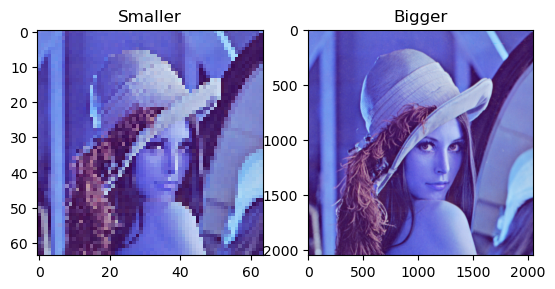

In [3]:
import matplotlib.pyplot as plt
half = cv2.resize(image,(64,64))
bigger = cv2.resize(image, (2048, 2048))
Titles =["Smaller","Bigger"]
images =[half, bigger]
count = 2
for i in range(count):
 plt.subplot(1, 2, i + 1)
 plt.title(Titles[i])
 plt.imshow(images[i])
plt.show()

**Image Resizing without Function**

In [9]:
import matplotlib.image as img
import cv2
import numpy as npy
m = img.imread("bird.png");
w, h = m.shape[:2];
xNew = int(w * 1 / 2);
yNew = int(h * 1 / 2);
xScale = xNew/(w-1);
yScale = yNew/(h-1);
newImage = npy.zeros([xNew, yNew,3]);
for i in range(xNew-1):
 for j in range(yNew-1):
     newImage[i + 1, j + 1]= m[1 + int(i / xScale),1 + int(j / yScale)]
img.imsave('scaled1.png', newImage);

**Grayscale With Function**

In [ ]:
import cv2
image = cv2.imread('Lenna.png')
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
cv2.imshow('Grayscale', gray_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

**Grayscale Without Function**

In [ ]:
m = img.imread("bird.png")
w, h = m.shape[:2]
newImage = npy.zeros([w, h, 3])
print( w )
print( h )

for i in range(w):
 for j in range(h):
 lst = [float(m[i][j][0]), float(m[i][j][1]), float(m[i][j][2])]
 avg = float(mean(lst))
 newImage[i][j][0] = avg
 newImage[i][j][1] = avg
 newImage[i][j][2] = avg
img.imsave('grayedImage2.png', newImage)


**Histogram Equalization With Function**

In [ ]:
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
equ = cv2.equalizeHist(gray_image)
res = np.hstack((gray_image, equ))
cv2.imshow("image", res)
cv2.waitKey(0)
cv2.destroyAllWindows()

**Histogram Equalization Without Function**

In [ ]:
def my_float2int(img):

 img = np.round(img, 0)
 img = np.minimum(img, 255)
 img = np.maximum(img, 0)
 img = img.astype('uint8')
 return img
def equalizeHistogram(img):

 img_height = img.shape[0]
 img_width = img.shape[1]
 histogram = np.zeros([256], np.int32)
 for i in range(0, img_height):
 for j in range(0, img_width):
 histogram[img[i, j]] +=1
 pdf_img = histogram / histogram.sum()
 cdf = np.zeros([256], float)
 for i in range(0, 256):
 for j in range(0, i+1):
 cdf[i] += pdf_img[j]
 cdf = np.zeros(256, float)
 cdf[0] = pdf_img[0]
 for i in range(1, 256):
 cdf[i] = cdf[i-1] + pdf_img[i]

 cdf_eq = np.round(cdf * 255, 0)

 imgEqualized = np.zeros((img_height, img_width))
 for i in range(0, img_height):
 for j in range(0, img_width):
 r = img[i, j]
 s = cdf_eq[r]
 imgEqualized[i, j] = s
 return imgEqualized
img_low = cv2.imread('Lenna.png', cv2.IMREAD_GRAYSCALE)
img_eq_low = equalizeHistogram(img_low)
img_eq_low = my_float2int(img_eq_low)
cv2.imshow('img_eq_low', img_eq_low)
cv2.waitKey(0)
cv2.destroyAllWindows()